# GNN Forecaster Comparison on METR-LA

KoopmanGraph is motivated against **nonlinear spatiotemporal GNN
forecasters** that learn convolutional and/or recurrent maps on graphs, rather
than enforcing linear evolution in a learned observable space. Until this

KoopmanGraph instead learns a linear latent advance of the form $z \leftarrow z K^{\top}$ (row-state convention).

notebook, the only in-repo baselines were classical **vector** DMD/EDMD —
useful, but not the comparison that motivation names.

> **Primary question:** under a shared METR-LA train/test split and horizon set,
> can a **rollout-trained** `GraphKoopmanModel` compete with lightweight STGCN /
> DCRNN / Graph WaveNet reference forecasters — while still exposing a linear
> latent operator (and spectrum) those GNN baselines lack?

We answer that with the packaged METR-LA weekday cache and shared
`evaluate_forecast` scoring. GraphKoopman uses the stronger METR-LA training
recipe from notebook 03 (wider latent model, ODO-bounded operator, ramp into
multi-step rollout loss, validation early stopping). The GNN models remain
**in-repo teaching baselines** in the lineage of Yu et al. (2018), Li et al.
(2018), and Wu et al. (2019) — not bit-exact dedicated traffic-library
reproductions.


## Methodology

| Model | Dynamics (paper lineage) |
|-------|--------------------------|
| `GraphKoopmanModel` | GNN encode → linear latent `K` step → GNN decode (ODO-bounded `K`; rollout-weighted fit) |
| `STGCNBaseline` | Gated temporal conv + graph-conv sandwich blocks (Yu, Yin & Zhu, IJCAI 2018; fully convolutional, not RNN) |
| `DCRNNBaseline` | Diffusion-convolutional GRU / DCGRU (Li, Yu, Shahabi & Liu, ICLR 2018) |
| `GraphWaveNetBaseline` | Dilated causal gated TCN + fixed/adaptive adjacency (Wu et al., IJCAI 2019; CNN-based, not RNN) |

**Protocol**

1. Load the packaged METR-LA weekday cache (`MetrLaTrafficBenchmark`).
2. Chronological `temporal_split` (70% / 10% / 20% train / val / test).
3. Fit GraphKoopman with a **rollout-aware** schedule (ramp reconstruction/forward →
   rollout; validate on the val split; early-stop). Fit GNN references with the
   same epoch budget and a shared teaching `HIDDEN` width.
4. Score multi-horizon RMSE on the held-out test window with
   `evaluate_forecast` (shared origins and horizons).

**Caveats**

- Architectures are not capacity-matched: GraphKoopman uses a wider latent
  encoder/decoder than the GNN teaching width, because a linear latent step needs
  enough observables to compete on multi-step traffic horizons. Parameter counts
  are printed below so the asymmetry is explicit.
- GNN baselines are simplified references (e.g. STGCN uses PyG ``GCNConv``, closer
  to ``STGCN(1st)`` than full Chebyshev; DCRNN is a compact DCGRU step, not full
  seq2seq + scheduled sampling; Graph WaveNet rolls out autoregressively). Our
  METR-LA artifact is a one-day teaching cache, not the full multi-month METR-LA
  from Li et al. / Wu et al.
- RMSE is in **z-scored** speed units from the cache.
- GNN baselines have **no** linear Koopman spectrum: ``spectrum()`` raises
  ``RuntimeError`` by design.
- Two runtime profiles are defined below (quick demo vs full run).


## Setup

Imports, seeds, and quick-demo vs full-demo budgets (epochs, widths, horizons).


In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import torch

from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
)
from koopman_graph.data import temporal_split
from koopman_graph.metrics import evaluate_forecast
from koopman_graph.baselines.gnn import (
    DCRNNBaseline,
    GraphWaveNetBaseline,
    STGCNBaseline,
)
from koopman_graph.datasets import MetrLaTrafficBenchmark
from koopman_graph.training import constant_loss_weights, linear_ramp_loss_weights

warnings.filterwarnings("ignore", category=UserWarning)
torch.manual_seed(0)

IS_TEST = bool(os.environ.get("PYTEST_CURRENT_TEST"))
# GraphKoopman: notebook-03-style capacity / budget.
# GNN refs: shared teaching width (not capacity-matched to GraphKoopman).
EPOCHS = 5 if IS_TEST else 120
RAMP_EPOCHS = 3 if IS_TEST else 40
GK_HIDDEN = 16 if IS_TEST else 64
GK_LATENT = 16 if IS_TEST else 64
GNN_HIDDEN = 8 if IS_TEST else 32
HORIZONS = (1, 2) if IS_TEST else (3, 6, 12)
LR_GK = 1.5e-3
LR_GNN = 1e-3


## Set up the problem

Load METR-LA topology and speeds, then build the chronological split used by
every model below. A quick-demo profile truncates the train/val/test windows;
the full path keeps the packaged weekday cache.


In [2]:
topology = MetrLaTrafficBenchmark.load_topology()
sequence = MetrLaTrafficBenchmark.load_sequence()
split = temporal_split(sequence)
train_seq = split.train
val_seq = split.val
test_seq = split.test

if IS_TEST:
    train_seq = train_seq.slice(0, min(24, train_seq.num_timesteps))
    val_seq = val_seq.slice(0, min(12, val_seq.num_timesteps))
    test_seq = test_seq.slice(0, min(16, test_seq.num_timesteps))

max_horizon = max(HORIZONS)
rollout_horizon = min(
    max_horizon,
    train_seq.num_timesteps - 1,
    val_seq.num_timesteps - 1,
)

print(
    f"sensors={topology.num_nodes}, edges={topology.edge_index.shape[1]}, "
    f"full cache T={sequence.num_timesteps}"
)
print(
    f"train/val/test timesteps: "
    f"{train_seq.num_timesteps} / {val_seq.num_timesteps} / {test_seq.num_timesteps}"
)
print(
    f"epochs={EPOCHS}, ramp={RAMP_EPOCHS}, "
    f"GK hidden/latent={GK_HIDDEN}/{GK_LATENT}, GNN hidden={GNN_HIDDEN}, "
    f"horizons={HORIZONS}, rollout_horizon={rollout_horizon}"
)


sensors=207, edges=2833, full cache T=288
train/val/test timesteps: 201 / 28 / 59
epochs=120, ramp=40, GK hidden/latent=64/64, GNN hidden=32, horizons=(3, 6, 12), rollout_horizon=12


### Snapshot of the traffic field

A few sensors from the train window — context for what the forecasters see
before we compare models. Flat segments are missing-speed imputation artifacts
in the METR-LA pipeline, not a plotting bug.


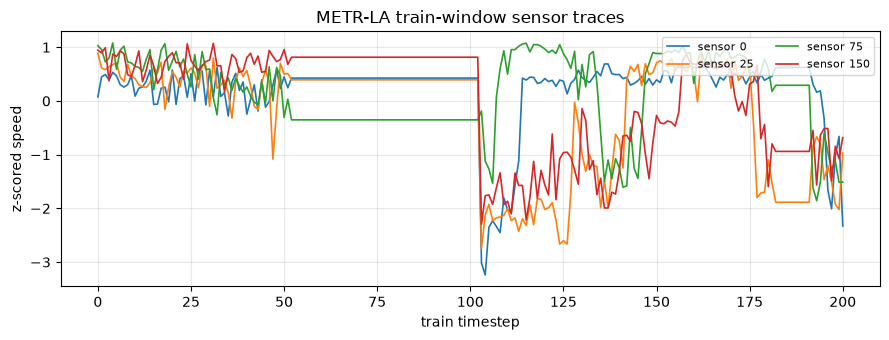

In [3]:
sensor_ids = [0, 25, 75, 150]
times = range(train_seq.num_timesteps)
fig, ax = plt.subplots(figsize=(9, 3.5))
for sid in sensor_ids:
    series = [float(train_seq[t].x[sid, 0]) for t in times]
    ax.plot(times, series, label=f"sensor {sid}", linewidth=1.2)
ax.set_xlabel("train timestep")
ax.set_ylabel("z-scored speed")
ax.set_title("METR-LA train-window sensor traces")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Run calculations

Fit a rollout-trained `GraphKoopmanModel` (ODO soft spectral bound, loss ramp
into multi-step rollout, validation early stopping), then fit the three GNN
reference baselines for the same number of epochs. Parameter counts are printed
so capacity differences are visible.


In [4]:
torch.manual_seed(0)
koopman = GraphKoopmanModel(
    encoder=GNNEncoder(1, GK_HIDDEN, GK_LATENT),
    decoder=GNNDecoder(GK_LATENT, GK_HIDDEN, 1),
    latent_dim=GK_LATENT,
    time_step=5.0,
    koopman_parameterization="odo",
    koopman_max_spectral_radius=1.05,
)

loss_schedule = linear_ramp_loss_weights(
    constant_loss_weights(
        reconstruction=1.0, forward=1.0, rollout=0.25, eigenvalue=0.05
    ),
    constant_loss_weights(
        reconstruction=1.0, forward=0.5, rollout=2.0, eigenvalue=0.05
    ),
    ramp_epochs=RAMP_EPOCHS,
)

history = koopman.fit(
    train_seq,
    validation_sequence=val_seq,
    epochs=EPOCHS,
    lr=LR_GK,
    loss_weight_schedule=loss_schedule,
    rollout_horizon=rollout_horizon,
    max_grad_norm=1.0,
    early_stopping_patience=30 if not IS_TEST else 5,
    restore_best_weights=True,
)

torch.manual_seed(0)
candidates = {
    "GraphKoopman": koopman,
    "STGCN": STGCNBaseline(
        1,
        GNN_HIDDEN,
        1,
        num_st_blocks=1 if IS_TEST else 2,
        history_len=2 if IS_TEST else 3,
    ).fit(train_seq, epochs=EPOCHS, lr=LR_GNN),
    "DCRNN": DCRNNBaseline(
        1,
        GNN_HIDDEN,
        1,
        diffusion_steps=1 if IS_TEST else 2,
        history_len=1,
    ).fit(train_seq, epochs=EPOCHS, lr=LR_GNN),
    "GraphWaveNet": GraphWaveNetBaseline(
        1,
        GNN_HIDDEN,
        1,
        num_layers=2 if IS_TEST else 4,
        history_len=2 if IS_TEST else 4,
        adaptive_adj=not IS_TEST,
    ).fit(train_seq, epochs=EPOCHS, lr=LR_GNN),
}

print(
    f"GraphKoopman final train loss={history.loss[-1]:.4f}; "
    f"best epoch tracked via early stopping / restore_best_weights"
)
print("Parameter counts:")
for name, model in candidates.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  {name:>12}: {n_params:,}")
print("fitted:", ", ".join(candidates))


GraphKoopman final train loss=1.1369; best epoch tracked via early stopping / restore_best_weights
Parameter counts:
  GraphKoopman: 16,769
         STGCN: 21,089
         DCRNN: 31,905
  GraphWaveNet: 47,681
fitted: GraphKoopman, STGCN, DCRNN, GraphWaveNet


## Display results

Score every model with `evaluate_forecast` on the held-out test window.

1. Print per-horizon and aggregate RMSE (lower is better), plus the aggregate ranking.
2. Bar chart of aggregate RMSE for a quick visual read.


In [5]:
rows = []
for name, model in candidates.items():
    result = evaluate_forecast(model, test_seq, horizons=HORIZONS)
    row = {"model": name, "aggregate": result.aggregate_rmse}
    for metric in result.horizons:
        row[f"h{metric.horizon}"] = metric.rmse
    rows.append(row)

header = ["model", *[f"h{h}" for h in HORIZONS], "aggregate"]
print("Multi-horizon test RMSE (z-scored speed; lower is better)")
print("  ".join(f"{col:>14}" for col in header))
for row in rows:
    cells_out = []
    for col in header:
        if col == "model":
            cells_out.append(f"{row['model']:>14}")
        else:
            cells_out.append(f"{row[col]:14.4f}")
    print("  ".join(cells_out))

ranked = sorted(rows, key=lambda r: r["aggregate"])
print(
    "Aggregate ranking (best → worst): "
    + " < ".join(r["model"] for r in ranked)
)


Multi-horizon test RMSE (z-scored speed; lower is better)
         model              h3              h6             h12       aggregate
  GraphKoopman          0.6515          0.6780          0.6824          0.6707
         STGCN          0.5549          0.6300          0.7631          0.6493
         DCRNN          0.5694          0.6510          0.7573          0.6592
  GraphWaveNet          0.5730          0.6476          0.8132          0.6779
Aggregate ranking (best → worst): STGCN < DCRNN < GraphKoopman < GraphWaveNet


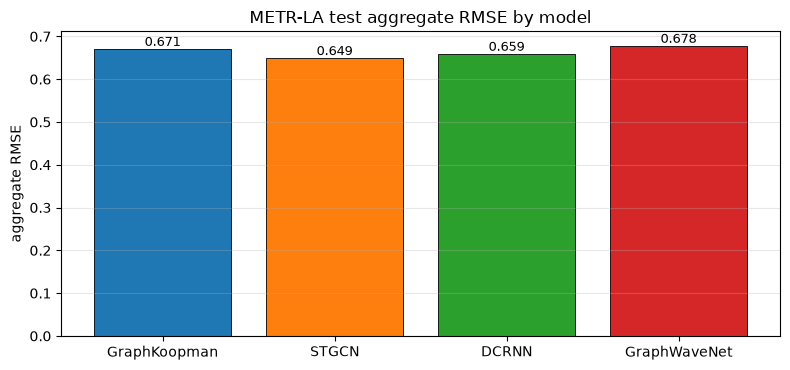

In [6]:
names = [row["model"] for row in rows]
aggregates = [row["aggregate"] for row in rows]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(names, aggregates, color=colors[: len(names)], edgecolor="black", linewidth=0.6)
ax.set_ylabel("aggregate RMSE")
ax.set_title("METR-LA test aggregate RMSE by model")
ax.grid(True, axis="y", alpha=0.3)
for bar, value in zip(bars, aggregates, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


## Interpret the results

Read the table and bar chart with the methodology caveats in mind:

- **Stored ranking (this run).** Aggregate test RMSE (lower better):
  **STGCN (0.65) < DCRNN (0.66) < GraphKoopman (0.67) < GraphWaveNet (0.68)**.
  GraphKoopman is now **competitive** with the GNN teaching baselines overall.
  At horizon 12 it is **best** (0.68 vs 0.76–0.81), which is the intended payoff
  of rollout-weighted training with an ODO-bounded linear operator. STGCN still
  leads at short horizons (h3/h6).
- **What this answers.** KoopmanGraph's motivating contrast is now *testable in
  repo*: a rollout-trained linear latent Koopman model vs nonlinear spatiotemporal
  GNN maps on the same METR-LA split, horizons, and scoring helper. Those GNN
  maps follow STGCN / DCRNN / Graph WaveNet *lineages*, not bit-exact published
  systems.
- **What the numbers mean.** Lower RMSE is better. GraphKoopman uses a stronger
  recipe and wider latent width than the GNN teaching width (see parameter
  counts). The near-tie on aggregate — with a clear long-horizon GraphKoopman
  win — supports using encode–linear–decode for this tutorial protocol when you
  care about multi-step stability **and** an inspectable operator. It does **not**
  claim dedicated-library traffic SOTA.
- **Where the models differ scientifically.** GraphKoopman keeps an explicit
  linear operator (and therefore a spectrum). The GNN forecasters learn nonlinear
  spatiotemporal predictors without a finite Koopman matrix; our baselines
  likewise expose no Koopman spectrum (`spectrum()` raises).
- **Relation to notebook 03.** Notebook 03 compares GraphKoopman to classical
  DMD/EDMD on METR-LA with the same rollout-aware recipe. This notebook adds the
  nonlinear GNN side of the motivation.


## Takeaways

- **Goal revisited:** a rollout-trained `GraphKoopmanModel` can compete with
  STGCN / DCRNN / Graph WaveNet teaching baselines under shared METR-LA
  evaluation — the missing nonlinear-GNN side of KoopmanGraph's motivation.
- **This run:** aggregate RMSE is a near-tie (STGCN slightly ahead); GraphKoopman
  wins at horizon 12. Prefer GraphKoopman when you want competitive multi-horizon
  forecasts **plus** an inspectable linear latent operator/spectrum.
- **Protocol:** same chronological split and horizons; GraphKoopman uses
  ODO + rollout ramp + early stopping; GNN refs share epoch count and teaching
  width (capacity not equalized — see parameter counts).
- **API:** `from koopman_graph.baselines.gnn import STGCNBaseline, DCRNNBaseline,
  GraphWaveNetBaseline`.
- **Honesty:** GNN numbers are teaching baselines, not published SOTA
  reproductions; spectral tools remain Koopman/DMD-family.
- **Next steps:** compare against notebook 03's DMD/EDMD rows; try notebook 24's
  chaotic benchmarks if you want a nonlinearity stress test instead of traffic.
